In [2]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv("../data/raw/stroke/stroke_raw.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# Remove ID because it is not a predictive feature

df = df.drop(columns=["id"])

print("Shape after removing ID:", df.shape)

df.head()

Shape after removing ID: (5110, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

X shape: (5110, 10)
y shape: (5110,)

Target distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Target percentage:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

X_train: (4088, 10)
X_test : (1022, 10)

Training target:
stroke
0    3889
1     199
Name: count, dtype: int64

Testing target:
stroke
0    972
1     50
Name: count, dtype: int64


In [7]:
numerical_features = [
    "age",
    "avg_glucose_level",
    "bmi"
]

categorical_features = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'avg_glucose_level', 'bmi']

Categorical Features:
['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [8]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [9]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape :", X_test_processed.shape)

Training processed shape: (4088, 23)
Testing processed shape : (1022, 23)


In [10]:
print("Any missing values in training data:",
      np.isnan(X_train_processed).sum())

print("Any missing values in testing data:",
      np.isnan(X_test_processed).sum())

Any missing values in training data: 0
Any missing values in testing data: 0


In [11]:
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier

print("Ensemble libraries imported successfully.")

Ensemble libraries imported successfully.


In [12]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(
            (y_train == 0).sum() /
            (y_train == 1).sum()
        ),
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

print("Total individual models:", len(models))

Total individual models: 10


In [13]:
results = []
trained_models = {}

for name, model in models.items():

    print(f"Training: {name}")

    model.fit(
        X_train_processed,
        y_train
    )

    y_pred = model.predict(
        X_test_processed
    )

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(
            X_test_processed
        )[:, 1]
    else:
        y_prob = None

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = (
        roc_auc_score(y_test, y_prob)
        if y_prob is not None
        else np.nan
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

    trained_models[name] = model


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

Training: Logistic Regression


Training: Decision Tree
Training: Random Forest
Training: Extra Trees
Training: SVM
Training: KNN


  File "c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Training: Gaussian Naive Bayes
Training: Gradient Boosting
Training: AdaBoost
Training: XGBoost


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,XGBoost,0.870841,0.184615,0.48,0.266667,0.824218
1,Logistic Regression,0.746575,0.138408,0.80,0.235988,0.843663
2,SVM,0.762231,0.127413,0.66,0.213592,0.801626
3,Gaussian Naive Bayes,0.322896,0.066216,0.98,0.124051,0.787119
4,Decision Tree,0.929550,0.156250,0.10,0.121951,0.536111
5,Extra Trees,0.941292,0.142857,0.04,0.062500,0.713344
6,Gradient Boosting,0.950098,0.333333,0.02,0.037736,0.829959
7,Random Forest,0.950098,0.000000,0.00,0.000000,0.778632
8,KNN,0.950098,0.000000,0.00,0.000000,0.647582
9,AdaBoost,0.951076,0.000000,0.00,0.000000,0.827088


In [14]:
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

results_display[metric_columns] = (
    results_display[metric_columns] * 100
).round(2)

results_display


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,XGBoost,87.08,18.46,48.0,26.67,82.42
1,Logistic Regression,74.66,13.84,80.0,23.60,84.37
2,SVM,76.22,12.74,66.0,21.36,80.16
3,Gaussian Naive Bayes,32.29,6.62,98.0,12.41,78.71
4,Decision Tree,92.95,15.62,10.0,12.20,53.61
5,Extra Trees,94.13,14.29,4.0,6.25,71.33
6,Gradient Boosting,95.01,33.33,2.0,3.77,83.00
7,Random Forest,95.01,0.00,0.0,0.00,77.86
8,KNN,95.01,0.00,0.0,0.00,64.76
9,AdaBoost,95.11,0.00,0.0,0.00,82.71


In [15]:
voting_estimators = [

    ("lr", models["Logistic Regression"]),

    ("dt", models["Decision Tree"]),

    ("rf", models["Random Forest"]),

    ("et", models["Extra Trees"]),

    ("svm", models["SVM"]),

    ("gb", models["Gradient Boosting"]),

    ("ada", models["AdaBoost"]),

    ("xgb", models["XGBoost"])
]

hard_voting = VotingClassifier(
    estimators=voting_estimators,
    voting="hard",
    n_jobs=-1
)

print("Hard Voting Ensemble created.")

Hard Voting Ensemble created.


In [16]:
print("Training Hard Voting Ensemble...")

hard_voting.fit(
    X_train_processed,
    y_train
)

hard_voting_pred = hard_voting.predict(
    X_test_processed
)

print("Hard Voting training completed.")

Training Hard Voting Ensemble...
Hard Voting training completed.


In [17]:
hard_accuracy = accuracy_score(
    y_test,
    hard_voting_pred
)

hard_precision = precision_score(
    y_test,
    hard_voting_pred,
    zero_division=0
)

hard_recall = recall_score(
    y_test,
    hard_voting_pred,
    zero_division=0
)

hard_f1 = f1_score(
    y_test,
    hard_voting_pred,
    zero_division=0
)

hard_voting_result = pd.DataFrame([{
    "Model": "Hard Voting",
    "Accuracy": hard_accuracy,
    "Precision": hard_precision,
    "Recall": hard_recall,
    "F1 Score": hard_f1
}])

hard_voting_result

,Model,Accuracy,Precision,Recall,F1 Score
0,Hard Voting,0.947162,0.0,0.0,0.0


In [18]:
hard_accuracy = accuracy_score(
    y_test,
    hard_voting_pred
)

hard_precision = precision_score(
    y_test,
    hard_voting_pred,
    zero_division=0
)

hard_recall = recall_score(
    y_test,
    hard_voting_pred,
    zero_division=0
)

hard_f1 = f1_score(
    y_test,
    hard_voting_pred,
    zero_division=0
)

hard_voting_result = pd.DataFrame([{
    "Model": "Hard Voting",
    "Accuracy": hard_accuracy,
    "Precision": hard_precision,
    "Recall": hard_recall,
    "F1 Score": hard_f1
}])

hard_voting_result

,Model,Accuracy,Precision,Recall,F1 Score
0,Hard Voting,0.947162,0.0,0.0,0.0


In [19]:
final_results = pd.concat(
    [
        results_df,
        hard_voting_result
    ],
    ignore_index=True
)

final_results = final_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,XGBoost,0.870841,0.184615,0.48,0.266667,0.824218
1,Logistic Regression,0.746575,0.138408,0.80,0.235988,0.843663
2,SVM,0.762231,0.127413,0.66,0.213592,0.801626
3,Gaussian Naive Bayes,0.322896,0.066216,0.98,0.124051,0.787119
4,Decision Tree,0.929550,0.156250,0.10,0.121951,0.536111
5,Extra Trees,0.941292,0.142857,0.04,0.062500,0.713344
6,Gradient Boosting,0.950098,0.333333,0.02,0.037736,0.829959
7,Random Forest,0.950098,0.000000,0.00,0.000000,0.778632
8,KNN,0.950098,0.000000,0.00,0.000000,0.647582
9,AdaBoost,0.951076,0.000000,0.00,0.000000,0.827088


In [20]:
final_display = final_results.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

final_display[metric_columns] = (
    final_display[metric_columns] * 100
).round(2)

final_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,XGBoost,87.08,18.46,48.0,26.67,0.824218
1,Logistic Regression,74.66,13.84,80.0,23.60,0.843663
2,SVM,76.22,12.74,66.0,21.36,0.801626
3,Gaussian Naive Bayes,32.29,6.62,98.0,12.41,0.787119
4,Decision Tree,92.95,15.62,10.0,12.20,0.536111
5,Extra Trees,94.13,14.29,4.0,6.25,0.713344
6,Gradient Boosting,95.01,33.33,2.0,3.77,0.829959
7,Random Forest,95.01,0.00,0.0,0.00,0.778632
8,KNN,95.01,0.00,0.0,0.00,0.647582
9,AdaBoost,95.11,0.00,0.0,0.00,0.827088


In [21]:
best_row = final_results.iloc[0]

print("===================================")
print("BEST MODEL")
print("===================================")

print("Model     :", best_row["Model"])
print("Accuracy  :", round(best_row["Accuracy"] * 100, 2), "%")
print("Precision :", round(best_row["Precision"] * 100, 2), "%")
print("Recall    :", round(best_row["Recall"] * 100, 2), "%")
print("F1 Score  :", round(best_row["F1 Score"] * 100, 2), "%")

BEST MODEL
Model     : XGBoost
Accuracy  : 87.08 %
Precision : 18.46 %
Recall    : 48.0 %
F1 Score  : 26.67 %


In [22]:
best_model_name = best_row["Model"]

if best_model_name == "Hard Voting":

    best_model = hard_voting

else:

    best_model = trained_models[best_model_name]

print("Selected Model:", best_model_name)

Selected Model: XGBoost


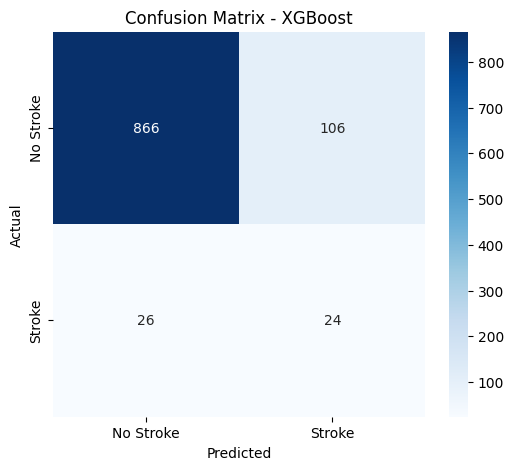

In [23]:
best_prediction = best_model.predict(
    X_test_processed
)

cm = confusion_matrix(
    y_test,
    best_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

In [24]:
os.makedirs(
    "../models/stroke",
    exist_ok=True
)

os.makedirs(
    "../results/stroke",
    exist_ok=True
)

# Save best model
joblib.dump(
    best_model,
    "../models/stroke/best_model.pkl"
)

# Save preprocessor
joblib.dump(
    preprocessor,
    "../models/stroke/preprocessor.pkl"
)

# Save comparison
final_results.to_csv(
    "../results/stroke/model_comparison.csv",
    index=False
)

print("========================================")
print("STROKE MODEL SAVED SUCCESSFULLY")
print("========================================")

print("Best Model:")
print(best_model_name)

print("\nModel:")
print("../models/stroke/best_model.pkl")

print("\nPreprocessor:")
print("../models/stroke/preprocessor.pkl")

print("\nComparison:")
print("../results/stroke/model_comparison.csv")

STROKE MODEL SAVED SUCCESSFULLY
Best Model:
XGBoost

Model:
../models/stroke/best_model.pkl

Preprocessor:
../models/stroke/preprocessor.pkl

Comparison:
../results/stroke/model_comparison.csv


In [25]:
print(
    "Best Model:",
    os.path.exists(
        "../models/stroke/best_model.pkl"
    )
)

print(
    "Preprocessor:",
    os.path.exists(
        "../models/stroke/preprocessor.pkl"
    )
)

print(
    "Comparison:",
    os.path.exists(
        "../results/stroke/model_comparison.csv"
    )
)

Best Model: True
Preprocessor: True
Comparison: True


In [26]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Before SMOTE:
stroke
0    3889
1     199
Name: count, dtype: int64

After SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64


In [27]:
smote_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

print("10 SMOTE models created.")


10 SMOTE models created.


In [28]:
smote_results = []
smote_trained_models = {}

for name, model in smote_models.items():

    print(f"Training: {name}")

    model.fit(
        X_train_smote,
        y_train_smote
    )

    y_pred = model.predict(
        X_test_processed
    )

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(
            X_test_processed
        )[:, 1]
    else:
        y_prob = None

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = (
        roc_auc_score(y_test, y_prob)
        if y_prob is not None
        else np.nan
    )

    smote_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

    smote_trained_models[name] = model


smote_results_df = pd.DataFrame(
    smote_results
)

smote_results_df = smote_results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

smote_results_df

Training: Logistic Regression
Training: Decision Tree


Training: Random Forest
Training: Extra Trees
Training: SVM
Training: KNN
Training: Gaussian Naive Bayes
Training: Gradient Boosting
Training: AdaBoost
Training: XGBoost


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gradient Boosting,0.869863,0.187970,0.50,0.273224,0.803868
1,Logistic Regression,0.747554,0.138889,0.80,0.236686,0.844115
2,XGBoost,0.913894,0.203125,0.26,0.228070,0.792222
3,SVM,0.802348,0.112245,0.44,0.178862,0.772428
4,AdaBoost,0.609589,0.096998,0.84,0.173913,0.824126
5,KNN,0.803327,0.104712,0.40,0.165975,0.673097
6,Decision Tree,0.887476,0.117647,0.20,0.148148,0.561420
7,Gaussian Naive Bayes,0.341487,0.067961,0.98,0.127108,0.785772
8,Random Forest,0.922701,0.128205,0.10,0.112360,0.765062
9,Extra Trees,0.919765,0.119048,0.10,0.108696,0.735484


In [29]:
smote_display = smote_results_df.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

smote_display[metrics] = (
    smote_display[metrics] * 100
).round(2)

smote_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gradient Boosting,86.99,18.80,50.0,27.32,80.39
1,Logistic Regression,74.76,13.89,80.0,23.67,84.41
2,XGBoost,91.39,20.31,26.0,22.81,79.22
3,SVM,80.23,11.22,44.0,17.89,77.24
4,AdaBoost,60.96,9.70,84.0,17.39,82.41
5,KNN,80.33,10.47,40.0,16.60,67.31
6,Decision Tree,88.75,11.76,20.0,14.81,56.14
7,Gaussian Naive Bayes,34.15,6.80,98.0,12.71,78.58
8,Random Forest,92.27,12.82,10.0,11.24,76.51
9,Extra Trees,91.98,11.90,10.0,10.87,73.55


In [30]:
threshold_results = []

threshold_models = {
    "Logistic Regression": smote_trained_models["Logistic Regression"],
    "Gradient Boosting": smote_trained_models["Gradient Boosting"],
    "XGBoost": smote_trained_models["XGBoost"]
}

thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

for model_name, model in threshold_models.items():

    probabilities = model.predict_proba(
        X_test_processed
    )[:, 1]

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        threshold_results.append({

            "Model": model_name,

            "Threshold": threshold,

            "Accuracy": accuracy_score(
                y_test,
                predictions
            ),

            "Precision": precision_score(
                y_test,
                predictions,
                zero_division=0
            ),

            "Recall": recall_score(
                y_test,
                predictions,
                zero_division=0
            ),

            "F1 Score": f1_score(
                y_test,
                predictions,
                zero_division=0
            )
        })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df = threshold_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

threshold_df

,Model,Threshold,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.50,0.869863,0.187970,0.50,0.273224
1,Gradient Boosting,0.45,0.848337,0.173913,0.56,0.265403
2,Gradient Boosting,0.40,0.821918,0.159794,0.62,0.254098
3,Logistic Regression,0.50,0.747554,0.138889,0.80,0.236686
4,XGBoost,0.40,0.875734,0.165217,0.38,0.230303
5,XGBoost,0.50,0.913894,0.203125,0.26,0.228070
6,Gradient Boosting,0.35,0.785714,0.137339,0.64,0.226148
7,XGBoost,0.45,0.897260,0.176471,0.30,0.222222
8,Logistic Regression,0.45,0.725049,0.128617,0.80,0.221607
9,XGBoost,0.35,0.855186,0.150000,0.42,0.221053


In [31]:
best_threshold_row = threshold_df.iloc[0]

print("Best Threshold Result")
print("=====================")

print("Model:",
      best_threshold_row["Model"])

print("Threshold:",
      best_threshold_row["Threshold"])

print("Accuracy:",
      round(best_threshold_row["Accuracy"] * 100, 2), "%")

print("Precision:",
      round(best_threshold_row["Precision"] * 100, 2), "%")

print("Recall:",
      round(best_threshold_row["Recall"] * 100, 2), "%")

print("F1 Score:",
      round(best_threshold_row["F1 Score"] * 100, 2), "%")

Best Threshold Result
Model: Gradient Boosting
Threshold: 0.5
Accuracy: 86.99 %
Precision: 18.8 %
Recall: 50.0 %
F1 Score: 27.32 %


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [33]:
lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", lr_grid.best_params_)
print("Best CV F1:", lr_grid.best_score_)

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Best CV F1: 0.7941736418864045


In [34]:
lr_best = lr_grid.best_estimator_

lr_pred = lr_best.predict(X_test_processed)
lr_prob = lr_best.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression")
print("===================")
print("Accuracy :", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, lr_pred, zero_division=0) * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, lr_pred, zero_division=0) * 100, 2), "%")
print("F1 Score :", round(f1_score(y_test, lr_pred, zero_division=0) * 100, 2), "%")
print("ROC AUC  :", round(roc_auc_score(y_test, lr_prob) * 100, 2), "%")

Logistic Regression
Accuracy : 74.17 %
Precision: 13.61 %
Recall   : 80.0 %
F1 Score : 23.26 %
ROC AUC  : 84.27 %


In [35]:
from xgboost import XGBClassifier

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_params,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

xgb_grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1: 0.9522092058720905


In [36]:
xgb_best = xgb_grid.best_estimator_

xgb_pred = xgb_best.predict(X_test_processed)
xgb_prob = xgb_best.predict_proba(X_test_processed)[:, 1]

print("XGBoost")
print("=======")
print("Accuracy :", round(accuracy_score(y_test, xgb_pred) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, xgb_pred, zero_division=0) * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, xgb_pred, zero_division=0) * 100, 2), "%")
print("F1 Score :", round(f1_score(y_test, xgb_pred, zero_division=0) * 100, 2), "%")
print("ROC AUC  :", round(roc_auc_score(y_test, xgb_prob) * 100, 2), "%")

XGBoost
Accuracy : 93.05 %
Precision: 25.58 %
Recall   : 22.0 %
F1 Score : 23.66 %
ROC AUC  : 78.08 %


In [37]:
from sklearn.ensemble import GradientBoostingClassifier

gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

gb_grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", gb_grid.best_params_)
print("Best CV F1:", gb_grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1: 0.9386356366253489


In [38]:
gb_best = gb_grid.best_estimator_

gb_pred = gb_best.predict(X_test_processed)
gb_prob = gb_best.predict_proba(X_test_processed)[:, 1]

print("Tuned Gradient Boosting")
print("======================")
print("Accuracy :", round(accuracy_score(y_test, gb_pred) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, gb_pred, zero_division=0) * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, gb_pred, zero_division=0) * 100, 2), "%")
print("F1 Score :", round(f1_score(y_test, gb_pred, zero_division=0) * 100, 2), "%")
print("ROC AUC  :", round(roc_auc_score(y_test, gb_prob) * 100, 2), "%")

Tuned Gradient Boosting
Accuracy : 91.78 %
Precision: 20.69 %
Recall   : 24.0 %
F1 Score : 22.22 %
ROC AUC  : 79.22 %


In [39]:
from sklearn.ensemble import VotingClassifier

hard_voting = VotingClassifier(
    estimators=[
        ("lr", smote_trained_models["Logistic Regression"]),
        ("dt", smote_trained_models["Decision Tree"]),
        ("rf", smote_trained_models["Random Forest"]),
        ("et", smote_trained_models["Extra Trees"]),
        ("svm", smote_trained_models["SVM"]),
        ("gb", smote_trained_models["Gradient Boosting"]),
        ("ada", smote_trained_models["AdaBoost"]),
        ("xgb", smote_trained_models["XGBoost"])
    ],
    voting="hard"
)

hard_voting.fit(X_train_smote, y_train_smote)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=2000,
                                                 random_state=42)),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('rf',
                              RandomForestClassifier(n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('et',
                              ExtraTreesClassifier(n_estimators=300, n_jobs=-1,
                                                   random_state=42)),
                             ('svm', SVC(probability=True, random_state=42)),
                             ('gb',
                              GradientBoostingCla...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=4,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=-1,
                                            num_parallel_tree=None, ...))])